<a href="https://colab.research.google.com/github/lyssethpitti-debug/Modelo-Matlab/blob/main/Tarea1_Grupo3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Parámetros de la simulación
  c  = 1.0       (velocidad de advección)
  N  = 60       (nodos espaciales)
  dx = 0.0167  (paso espacial)
  dt = 0.0080  (paso temporal)
  nu = 0.4800  (número de Courant CFL = c*dt/dx)
  M  = 50       (pasos de tiempo totales)
  T  = 0.4       (tiempo final)

  ✓ Condición CFL satisfecha: nu = 0.4800 <= 1

Generando Figura 1: Caso trivial...


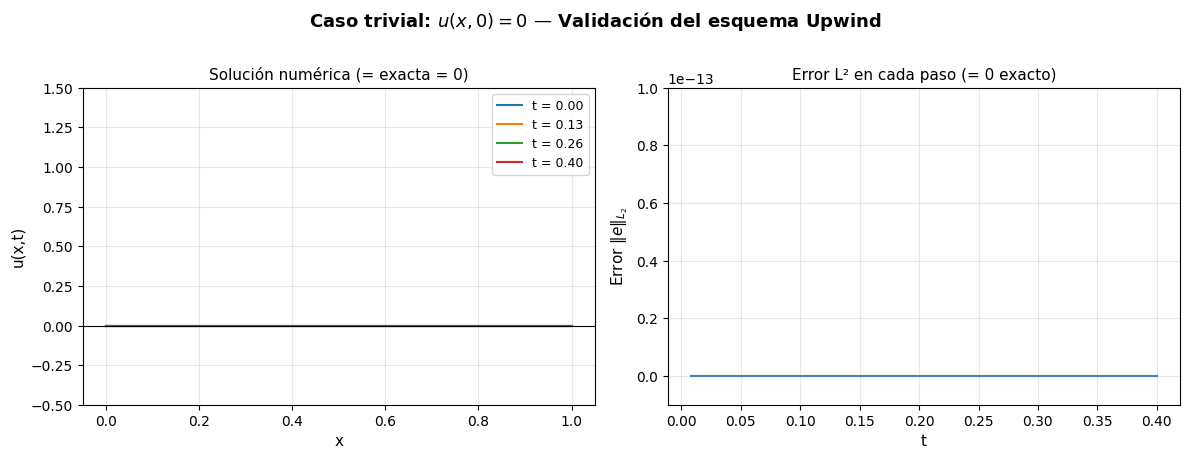

  → fig1_trivial.png guardada

Generando Figura 2: Escalón suavizado...


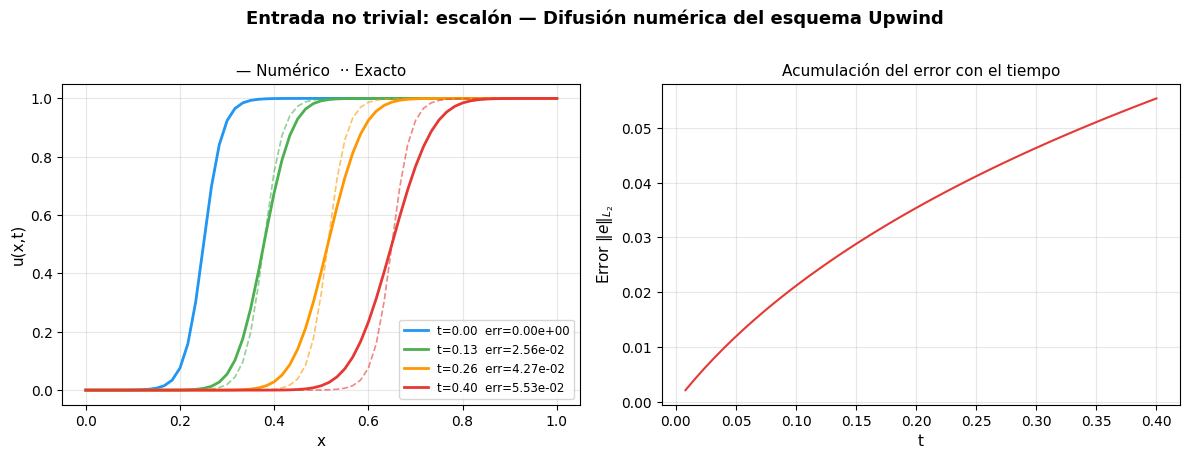

  → fig2_escalon.png guardada

Generando Figura 3: Pulso gaussiano...


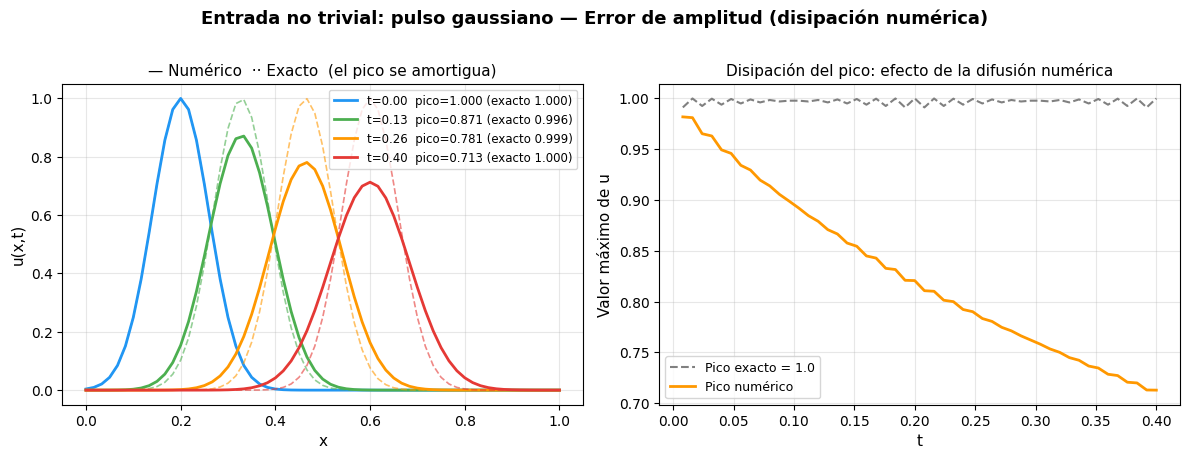

  → fig3_gaussiana.png guardada

Generando Figura 4: Upwind vs Centrado...


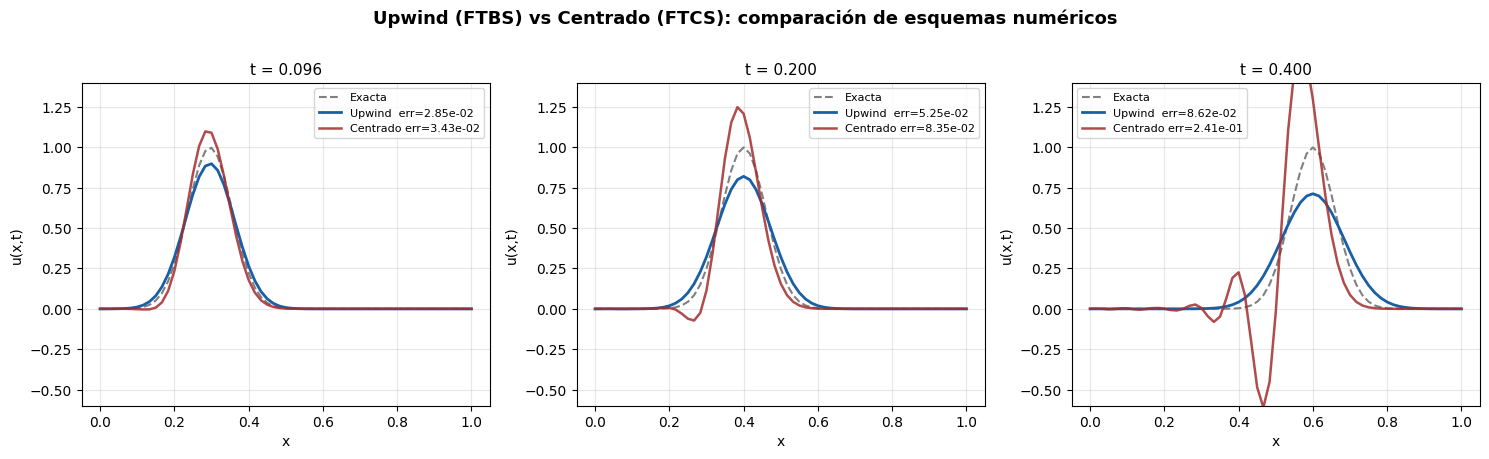

  → fig4_comparacion_esquemas.png guardada

Generando Figura 5: Tabla de errores...


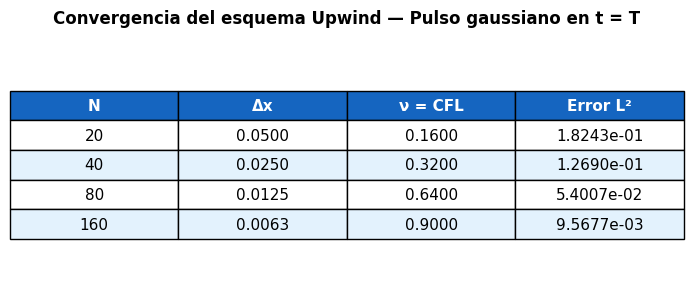

  → fig5_tabla_convergencia.png guardada

Generando Figura 6: Análisis de estabilidad Von Neumann...


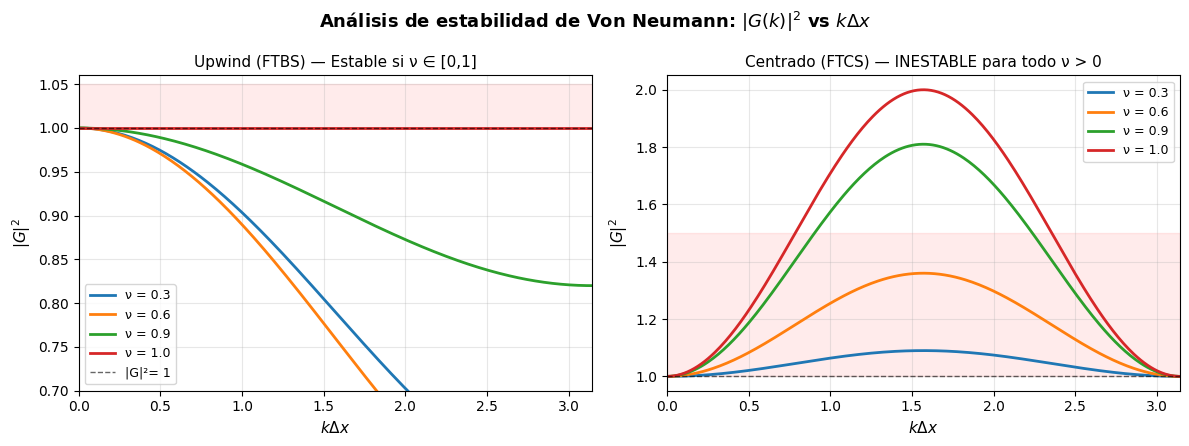

  → fig6_von_neumann.png guardada

  RESUMEN — Resultados finales (t = T)
  Caso trivial   → Error L²: 0.00e+00
  Escalón        → Error L²: 5.53e-02
  Gaussiana UP   → Error L²: 8.62e-02
  Gaussiana CEN  → Error L²: 2.41e-01  (inestable)

  Figuras generadas:
    fig1_trivial.png
    fig2_escalon.png
    fig3_gaussiana.png
    fig4_comparacion_esquemas.png
    fig5_tabla_convergencia.png
    fig6_von_neumann.png


In [1]:
# ============================================================
# Tarea_1 - Métodos Numéricos Avanzados  |  Grupo 3
# Asignación: Ecuación de Advección Lineal
#   u_t + c*u_x = 0,   0 < x < 1,   0 < t <= T
#
# Esquemas implementados:
#   1. Caso trivial        u(x,0) = 0           (validación)
#   2. Upwind + Escalón    u(x,0) = tanh(...)   (frente abrupto)
#   3. Upwind + Gaussiana  u(x,0) = exp(...)    (pulso suave)
#   4. Upwind vs Centrado  (comparación de esquemas)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ============================================================
# PARÁMETROS GLOBALES
# ============================================================

c  = 1.0      # velocidad de advección (c > 0 → transporte hacia la derecha)
T  = 0.4      # tiempo final de simulación
N  = 60       # número de intervalos espaciales  →  dx = 1/N
dt = 0.008    # paso de tiempo
# Número de Courant (CFL): nu = c*dt/dx  →  debe estar en [0, 1] para estabilidad
dx = 1.0 / N
nu = c * dt / dx

# Malla espacial: N+1 nodos en [0, 1]
x = np.linspace(0, 1, N + 1)   # x_i = i * dx,  i = 0, 1, ..., N

# Número de pasos de tiempo
M = int(T / dt)                  # M pasos  →  t_n = n * dt

print("=" * 50)
print("  Parámetros de la simulación")
print("=" * 50)
print(f"  c  = {c}       (velocidad de advección)")
print(f"  N  = {N}       (nodos espaciales)")
print(f"  dx = {dx:.4f}  (paso espacial)")
print(f"  dt = {dt:.4f}  (paso temporal)")
print(f"  nu = {nu:.4f}  (número de Courant CFL = c*dt/dx)")
print(f"  M  = {M}       (pasos de tiempo totales)")
print(f"  T  = {T}       (tiempo final)")
if nu <= 1.0:
    print(f"\n  ✓ Condición CFL satisfecha: nu = {nu:.4f} <= 1")
else:
    print(f"\n  ✗ ADVERTENCIA: CFL violada: nu = {nu:.4f} > 1 → inestabilidad")
print()


# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def norma_L2(u_num, u_ex):
    """
    Calcula el error en norma L2 discreta entre la solución
    numérica y la exacta:
        ||e||_L2 = sqrt( (1/N) * sum( (u_num_i - u_ex_i)^2 ) )
    """
    return np.sqrt(np.mean((u_num - u_ex) ** 2))


# ============================================================
# ESQUEMA NUMÉRICO 1: UPWIND (FTBS)
# ============================================================
# Aproximación:
#   ∂u/∂t  ≈  (u_i^{n+1} - u_i^n) / dt     (diferencia adelante en t)
#   ∂u/∂x  ≈  (u_i^n - u_{i-1}^n) / dx     (diferencia atrás en x, upwind)
#
# Ecuación discreta final:
#   u_i^{n+1} = u_i^n - nu * (u_i^n - u_{i-1}^n)
#
# Estabilidad: 0 <= nu <= 1  (condición de Courant-Friedrichs-Lewy)

def upwind(u0, bc_func, steps):
    """
    Aplica el esquema Upwind (FTBS) para la advección lineal.

    Parámetros
    ----------
    u0      : array (N+1,)   condición inicial u(x, 0)
    bc_func : callable       función bc_func(t) → valor en x=0
    steps   : int            número de pasos de tiempo a avanzar

    Retorna
    -------
    u : array (N+1,)   solución en t = steps * dt
    """
    u = u0.copy()
    for n in range(steps):
        t_nuevo = (n + 1) * dt
        u_nueva = np.empty_like(u)

        # Condición de frontera en x=0 (frontera de entrada para c>0)
        u_nueva[0] = bc_func(t_nuevo)

        # Esquema Upwind en los nodos interiores y frontera derecha
        # u_i^{n+1} = u_i^n - nu * (u_i^n - u_{i-1}^n)
        u_nueva[1:] = u[1:] - nu * (u[1:] - u[:-1])

        u = u_nueva
    return u


# ============================================================
# ESQUEMA NUMÉRICO 2: CENTRADO (FTCS)
# ============================================================
# Aproximación:
#   ∂u/∂t  ≈  (u_i^{n+1} - u_i^n) / dt                (adelante en t)
#   ∂u/∂x  ≈  (u_{i+1}^n - u_{i-1}^n) / (2*dx)        (centrada en x)
#
# Ecuación discreta:
#   u_i^{n+1} = u_i^n - (nu/2) * (u_{i+1}^n - u_{i-1}^n)
#
# ¡IMPORTANTE! Análisis de Von Neumann:
#   Factor de amplificación: |G|^2 = 1 + nu^2 * sin^2(k*dx) > 1
#   → Incondicionalmente INESTABLE para todo nu > 0.
#   El error crece exponencialmente en cada paso de tiempo.

def centrado(u0, bc_func, steps):
    """
    Aplica el esquema Centrado (FTCS) para la advección lineal.
    ADVERTENCIA: este esquema es inestable para la advección pura.
    Se incluye únicamente con fines comparativos / didácticos.
    """
    u = u0.copy()
    for n in range(steps):
        t_nuevo = (n + 1) * dt
        u_nueva = np.empty_like(u)

        # Frontera de entrada
        u_nueva[0] = bc_func(t_nuevo)

        # Diferencia centrada en nodos interiores
        # u_i^{n+1} = u_i^n - (nu/2)*(u_{i+1}^n - u_{i-1}^n)
        u_nueva[1:-1] = u[1:-1] - (nu / 2) * (u[2:] - u[:-2])

        # Frontera derecha: usamos Upwind para no necesitar un nodo fantasma
        u_nueva[-1] = u[-1] - nu * (u[-1] - u[-2])

        u = u_nueva
    return u


# ============================================================
# CONDICIONES INICIALES Y DE FRONTERA
# ============================================================

# --- CASO 1: Trivial ---
def ci_trivial(x):
    """u(x,0) = 0  para todo x."""
    return np.zeros_like(x)

def bc_trivial(t):
    """u(0,t) = 0  (frontera compatible con CI trivial)."""
    return 0.0

def sol_exacta_trivial(x, t):
    """Solución exacta: u(x,t) = 0."""
    return np.zeros_like(x)


# --- CASO 2: Escalón suavizado (Heaviside via tanh) ---
x0_esc = 0.25   # posición inicial del frente

def ci_escalon(x):
    """
    u(x,0) = 0.5 * [1 + tanh((x - x0) / ancho)]
    Escalón suave centrado en x0=0.25, ancho de transición = 0.04.
    Modela: frente de contaminante, onda de choque suavizada.
    """
    return 0.5 * (1.0 + np.tanh((x - x0_esc) / 0.04))

def bc_escalon(t):
    """Valor exacto de la solución en x=0 para imponer BC."""
    return 0.5 * (1.0 + np.tanh((0.0 - x0_esc - c * t) / 0.04))

def sol_exacta_escalon(x, t):
    """u(x,t) = u0(x - c*t)  →  el escalón viaja a velocidad c."""
    return 0.5 * (1.0 + np.tanh((x - x0_esc - c * t) / 0.04))


# --- CASO 3: Pulso gaussiano ---
x0_g = 0.2    # centro inicial del pulso
sig  = 0.06   # desviación estándar (ancho del pulso)

def ci_gauss(x):
    """
    u(x,0) = exp( -(x - x0)^2 / (2*sigma^2) )
    Pulso gaussiano centrado en x0=0.2.
    Modela: pulso de temperatura, concentración puntual.
    """
    return np.exp(-((x - x0_g) ** 2) / (2 * sig ** 2))

def bc_gauss(t):
    """Valor exacto de la solución gaussiana en x=0."""
    return np.exp(-((0.0 - x0_g - c * t) ** 2) / (2 * sig ** 2))

def sol_exacta_gauss(x, t):
    """u(x,t) = exp(-(x - x0 - c*t)^2 / (2*sigma^2))."""
    return np.exp(-((x - x0_g - c * t) ** 2) / (2 * sig ** 2))


# ============================================================
# PASOS DE TIEMPO A GRAFICAR (instantes representativos)
# ============================================================
# Graficamos en t=0, t=T/3, t=2T/3, t=T
pasos = [0, M // 3, 2 * M // 3, M]
tiempos = [p * dt for p in pasos]


# ============================================================
# FIGURA 1: CASO TRIVIAL — VALIDACIÓN DEL MÉTODO
# ============================================================
print("Generando Figura 1: Caso trivial...")

fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4.5))
fig1.suptitle(
    "Caso trivial: $u(x,0) = 0$ — Validación del esquema Upwind",
    fontsize=13, fontweight="bold", y=1.01
)

# Panel izquierdo: solución en varios instantes
ax = axes1[0]
u = ci_trivial(x)
for p in pasos:
    u_num = upwind(ci_trivial(x), bc_trivial, p)
    ax.plot(x, u_num, label=f"t = {p*dt:.2f}")

ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("u(x,t)", fontsize=11)
ax.set_title("Solución numérica (= exacta = 0)", fontsize=11)
ax.set_ylim(-0.5, 1.5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(0, color="k", lw=0.8)

# Panel derecho: error en cada paso (debe ser 0 siempre)
ax2 = axes1[1]
errores = []
u_ev = ci_trivial(x)
for n in range(M):
    u_ev = upwind(u_ev, bc_trivial, 1)  # avanzar un paso
    errores.append(norma_L2(u_ev, sol_exacta_trivial(x, (n+1)*dt)))

ax2.plot(np.arange(1, M+1) * dt, errores, color="steelblue", lw=1.5)
ax2.set_xlabel("t", fontsize=11)
ax2.set_ylabel("Error $\\|e\\|_{L_2}$", fontsize=11)
ax2.set_title("Error L² en cada paso (= 0 exacto)", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-1e-14, 1e-13)

plt.tight_layout()
plt.savefig("fig1_trivial.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig1_trivial.png guardada\n")


# ============================================================
# FIGURA 2: ESCALÓN — DIFUSIÓN NUMÉRICA DEL UPWIND
# ============================================================
print("Generando Figura 2: Escalón suavizado...")

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5))
fig2.suptitle(
    "Entrada no trivial: escalón — Difusión numérica del esquema Upwind",
    fontsize=13, fontweight="bold", y=1.01
)

colores = ["#2196F3", "#4CAF50", "#FF9800", "#E53935"]

# Panel izquierdo: evolución temporal
ax = axes2[0]
for i, p in enumerate(pasos):
    t_p = p * dt
    u_num = upwind(ci_escalon(x), bc_escalon, p)
    u_ex  = sol_exacta_escalon(x, t_p)
    ax.plot(x, u_ex,  "--", color=colores[i], alpha=0.6, lw=1.2)
    ax.plot(x, u_num, "-",  color=colores[i], lw=2,
            label=f"t={t_p:.2f}  err={norma_L2(u_num, u_ex):.2e}")

ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("u(x,t)", fontsize=11)
ax.set_title("— Numérico  ·· Exacto", fontsize=11)
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

# Panel derecho: error L2 acumulado
ax2 = axes2[1]
errores_esc = []
u_ev = ci_escalon(x)
for n in range(M):
    u_ev = upwind(u_ev, bc_escalon, 1)
    errores_esc.append(norma_L2(u_ev, sol_exacta_escalon(x, (n+1)*dt)))

ax2.plot(np.arange(1, M+1)*dt, errores_esc, color="#E53935", lw=1.5)
ax2.set_xlabel("t", fontsize=11)
ax2.set_ylabel("Error $\\|e\\|_{L_2}$", fontsize=11)
ax2.set_title("Acumulación del error con el tiempo", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig2_escalon.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig2_escalon.png guardada\n")


# ============================================================
# FIGURA 3: GAUSSIANA — ERROR DE AMPLITUD
# ============================================================
print("Generando Figura 3: Pulso gaussiano...")

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4.5))
fig3.suptitle(
    "Entrada no trivial: pulso gaussiano — Error de amplitud (disipación numérica)",
    fontsize=13, fontweight="bold", y=1.01
)

ax = axes3[0]
for i, p in enumerate(pasos):
    t_p = p * dt
    u_num = upwind(ci_gauss(x), bc_gauss, p)
    u_ex  = sol_exacta_gauss(x, t_p)
    ax.plot(x, u_ex,  "--", color=colores[i], alpha=0.6, lw=1.2)
    pico_num = u_num.max()
    pico_ex  = u_ex.max()
    ax.plot(x, u_num, "-", color=colores[i], lw=2,
            label=f"t={t_p:.2f}  pico={pico_num:.3f} (exacto {pico_ex:.3f})")

ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("u(x,t)", fontsize=11)
ax.set_title("— Numérico  ·· Exacto  (el pico se amortigua)", fontsize=11)
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

# Panel derecho: evolución del pico numérico vs exacto
ax2 = axes3[1]
picos_num, picos_ex = [], []
u_ev = ci_gauss(x)
for n in range(M):
    u_ev = upwind(u_ev, bc_gauss, 1)
    t_n  = (n+1)*dt
    picos_num.append(u_ev.max())
    picos_ex.append(sol_exacta_gauss(x, t_n).max())

t_vec = np.arange(1, M+1)*dt
ax2.plot(t_vec, picos_ex,  "--", color="gray", lw=1.5, label="Pico exacto = 1.0")
ax2.plot(t_vec, picos_num, "-",  color="#FF9800", lw=2,   label="Pico numérico")
ax2.set_xlabel("t", fontsize=11)
ax2.set_ylabel("Valor máximo de u", fontsize=11)
ax2.set_title("Disipación del pico: efecto de la difusión numérica", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig3_gaussiana.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig3_gaussiana.png guardada\n")


# ============================================================
# FIGURA 4: UPWIND vs CENTRADO — COMPARACIÓN DE ESQUEMAS
# ============================================================
print("Generando Figura 4: Upwind vs Centrado...")

# Usamos la gaussiana como entrada (revela mejor las diferencias)
fig4, axes4 = plt.subplots(1, 3, figsize=(15, 4.5))
fig4.suptitle(
    "Upwind (FTBS) vs Centrado (FTCS): comparación de esquemas numéricos",
    fontsize=13, fontweight="bold", y=1.01
)

# Tres instantes para la comparación
pasos_cmp = [M // 4, M // 2, M]
for ax, p in zip(axes4, pasos_cmp):
    t_p   = p * dt
    u_up  = upwind(ci_gauss(x),   bc_gauss, p)
    u_cen = centrado(ci_gauss(x), bc_gauss, p)
    u_ex  = sol_exacta_gauss(x, t_p)

    err_up  = norma_L2(u_up,  u_ex)
    err_cen = norma_L2(u_cen, u_ex)

    ax.plot(x, u_ex,  "--", color="gray",    lw=1.5, label="Exacta")
    ax.plot(x, u_up,  "-",  color="#185FA5", lw=2,
            label=f"Upwind  err={err_up:.2e}")
    ax.plot(x, u_cen, "-",  color="#A32D2D", lw=1.8, alpha=0.85,
            label=f"Centrado err={err_cen:.2e}")

    ax.set_title(f"t = {t_p:.3f}", fontsize=11)
    ax.set_xlabel("x", fontsize=10)
    ax.set_ylabel("u(x,t)", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    # Limitar eje y para que las oscilaciones del centrado no distorsionen todo
    ax.set_ylim(-0.6, 1.4)

plt.tight_layout()
plt.savefig("fig4_comparacion_esquemas.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig4_comparacion_esquemas.png guardada\n")


# ============================================================
# FIGURA 5: TABLA DE ERRORES — ANÁLISIS DE CONVERGENCIA
# ============================================================
print("Generando Figura 5: Tabla de errores...")

# Refinamos la malla para ver convergencia del Upwind
Ns    = [20, 40, 80, 160]     # distintos números de nodos
errores_conv = []

for Ni in Ns:
    dxi  = 1.0 / Ni
    nui  = c * dt / dxi        # Courant para cada malla
    if nui > 1.0:
        # Si CFL se viola, ajustamos dt para este N
        dti = 0.9 * dxi / c
    else:
        dti = dt
    Mi   = int(T / dti)
    xi   = np.linspace(0, 1, Ni + 1)
    nui  = c * dti / dxi

    # Avanzar M pasos con Upwind (gaussiana)
    u_ev = np.exp(-((xi - x0_g)**2) / (2*sig**2))
    for n in range(Mi):
        t_n   = (n+1)*dti
        u_new = np.empty_like(u_ev)
        u_new[0]  = np.exp(-((0 - x0_g - c*t_n)**2) / (2*sig**2))
        u_new[1:] = u_ev[1:] - nui*(u_ev[1:] - u_ev[:-1])
        u_ev = u_new

    u_ex_fin = np.exp(-((xi - x0_g - c*T)**2) / (2*sig**2))
    err = np.sqrt(np.mean((u_ev - u_ex_fin)**2))
    errores_conv.append((Ni, dxi, nui, err))

fig5, ax5 = plt.subplots(figsize=(7, 3))
ax5.axis("off")

headers = ["N", "Δx", "ν = CFL", "Error L²"]
tabla   = [[str(e[0]), f"{e[1]:.4f}", f"{e[2]:.4f}", f"{e[3]:.4e}"]
           for e in errores_conv]

t_obj = ax5.table(
    cellText=tabla,
    colLabels=headers,
    loc="center",
    cellLoc="center"
)
t_obj.auto_set_font_size(False)
t_obj.set_fontsize(11)
t_obj.scale(1.2, 1.8)

# Encabezado con color
for j in range(4):
    t_obj[(0, j)].set_facecolor("#1565C0")
    t_obj[(0, j)].set_text_props(color="white", fontweight="bold")
# Filas alternas
for i in range(1, len(tabla)+1):
    fc = "#E3F2FD" if i % 2 == 0 else "white"
    for j in range(4):
        t_obj[(i, j)].set_facecolor(fc)

ax5.set_title(
    "Convergencia del esquema Upwind — Pulso gaussiano en t = T",
    fontsize=12, fontweight="bold", pad=20
)
plt.tight_layout()
plt.savefig("fig5_tabla_convergencia.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig5_tabla_convergencia.png guardada\n")


# ============================================================
# FIGURA 6: ANÁLISIS DE VON NEUMANN — FACTOR DE AMPLIFICACIÓN
# ============================================================
print("Generando Figura 6: Análisis de estabilidad Von Neumann...")

# El factor de amplificación G(k) determina si los modos de Fourier
# crecen (|G|>1 → inestable) o decrecen/permanecen (|G|<=1 → estable).
#
# Upwind:   G = 1 - nu*(1 - exp(-i*k*dx))
#   |G|^2  = 1 - 2*nu*(1-nu)*sin^2(k*dx/2)  <=  1  si 0<=nu<=1
#
# Centrado: G = 1 - i*nu*sin(k*dx)
#   |G|^2  = 1 + nu^2 * sin^2(k*dx)  >  1  siempre → INESTABLE

k_dx = np.linspace(0, np.pi, 300)   # k*dx ∈ [0, π]

nus_plot = [0.3, 0.6, 0.9, 1.0]     # distintos valores de CFL

fig6, axes6 = plt.subplots(1, 2, figsize=(12, 4.5))
fig6.suptitle(
    "Análisis de estabilidad de Von Neumann: $|G(k)|^2$ vs $k\\Delta x$",
    fontsize=13, fontweight="bold"
)

# --- Upwind ---
ax = axes6[0]
for nui in nus_plot:
    G2 = 1 - 2*nui*(1-nui)*np.sin(k_dx/2)**2
    ax.plot(k_dx, G2, lw=2, label=f"ν = {nui}")
ax.axhline(1.0, color="k", lw=1, ls="--", alpha=0.6, label="|G|²= 1")
ax.fill_between(k_dx, 1.0, 1.05, alpha=0.08, color="red")
ax.set_xlabel("$k\\Delta x$", fontsize=11)
ax.set_ylabel("$|G|^2$", fontsize=11)
ax.set_title("Upwind (FTBS) — Estable si ν ∈ [0,1]", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.7, 1.06)
ax.set_xlim(0, np.pi)

# --- Centrado ---
ax2 = axes6[1]
for nui in nus_plot:
    G2 = 1 + nui**2 * np.sin(k_dx)**2
    ax2.plot(k_dx, G2, lw=2, label=f"ν = {nui}")
ax2.axhline(1.0, color="k", lw=1, ls="--", alpha=0.6)
ax2.fill_between(k_dx, 1.0, ax2.get_ylim()[1] if False else 1.5,
                 alpha=0.08, color="red")
ax2.set_xlabel("$k\\Delta x$", fontsize=11)
ax2.set_ylabel("$|G|^2$", fontsize=11)
ax2.set_title("Centrado (FTCS) — INESTABLE para todo ν > 0", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, np.pi)

plt.tight_layout()
plt.savefig("fig6_von_neumann.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig6_von_neumann.png guardada\n")


# ============================================================
# RESUMEN FINAL EN CONSOLA
# ============================================================
print("=" * 50)
print("  RESUMEN — Resultados finales (t = T)")
print("=" * 50)
u_triv = upwind(ci_trivial(x), bc_trivial,  M)
u_esc  = upwind(ci_escalon(x), bc_escalon,  M)
u_gss  = upwind(ci_gauss(x),   bc_gauss,    M)
u_cen  = centrado(ci_gauss(x), bc_gauss,    M)

print(f"  Caso trivial   → Error L²: {norma_L2(u_triv, sol_exacta_trivial(x, T)):.2e}")
print(f"  Escalón        → Error L²: {norma_L2(u_esc,  sol_exacta_escalon(x, T)):.2e}")
print(f"  Gaussiana UP   → Error L²: {norma_L2(u_gss,  sol_exacta_gauss(x, T)):.2e}")
print(f"  Gaussiana CEN  → Error L²: {norma_L2(u_cen,  sol_exacta_gauss(x, T)):.2e}  (inestable)")
print()
print("  Figuras generadas:")
print("    fig1_trivial.png")
print("    fig2_escalon.png")
print("    fig3_gaussiana.png")
print("    fig4_comparacion_esquemas.png")
print("    fig5_tabla_convergencia.png")
print("    fig6_von_neumann.png")
print("=" * 50)